### Agent-Lab: Adaptive RAG Agent

Objective of this notebook is evaluating and adapting the implementation of [Adaptive RAG Agent](https://langchain-ai.github.io/langgraph/tutorials/rag/langgraph_adaptive_rag/).


In [1]:
%%capture
import json
import os
import nest_asyncio
from dotenv import load_dotenv
from IPython.display import Markdown, display
from notebooks import experiment_utils
from agent_lab.interface.api.messages.schema import MessageRequest

os.chdir("..")
load_dotenv()
nest_asyncio.apply()

# start dependency injection container
container = experiment_utils.bootstrap_container([__name__])

# get checkpointer instance
graph_persistence_factory = container.graph_persistence_factory()
checkpointer = graph_persistence_factory.build_checkpoint_saver()

---

## XAI Adaptive RAG Agent

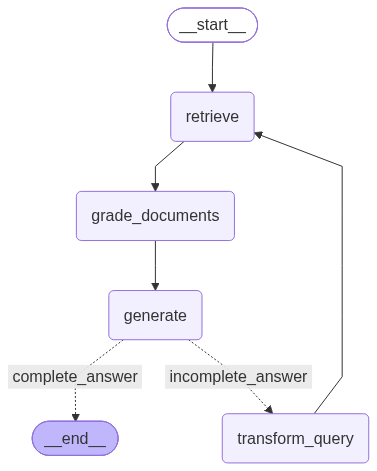

In [37]:
# Create Workflow
xai_agent = experiment_utils.create_xai_agent(
    agent_type="adaptive_rag", llm_tag="grok-build-latest", api_key=os.getenv("XAI_API_KEY")
)
xai_adaptive_rag_agent = container.agent_registry().get_agent("adaptive_rag")
xai_workflow_builder = xai_adaptive_rag_agent.get_workflow_builder(xai_agent["id"])
xai_workflow = xai_workflow_builder.compile(checkpointer=checkpointer)
experiment_utils.print_graph(xai_workflow)

In [3]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="According to the supplied context, what is the pinnacle of excellence?",
    agent_id=xai_agent["id"],
)

inputs = xai_adaptive_rag_agent.get_input_params(message, schema="public")
config = xai_adaptive_rag_agent.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_adaptive_rag_agent.format_response(result)

In [4]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

According to the context, the pinnacle (supreme/acme) of excellence is breaking the enemy’s resistance without fighting—winning by foiling their plans and schemes so the day is won without shedding a drop of blood.

In [5]:
display(
    Markdown(
        f"**Workflow state:**\n```json\n{json.dumps(workflow_state, indent=2)}\n```"
    )
)

**Workflow state:**
```json
{
  "agent_id": "43d50f10-7b64-4d8d-91bd-194f1661e9f9",
  "query": "According to the supplied context, what is the pinnacle of excellence?",
  "collection_name": "static_document_data_ollama_embeddings",
  "generation": "According to the context, the pinnacle (supreme/acme) of excellence is breaking the enemy\u2019s resistance without fighting\u2014winning by foiling their plans and schemes so the day is won without shedding a drop of blood.",
  "connection": "The query asks for the pinnacle of excellence per the supplied Sun Tzu context, which equates supreme/acme excellence with defeating the enemy without combat.",
  "documents": [
    "2. Hence to fight and conquer in all your battles is not supreme excellence;\nsupreme excellence consists in breaking the enemy\u2019s resistance without\nfighting.\n\n[Here again, no modern strategist but will approve the words of the old Chinese\ngeneral. Moltke\u2019s greatest triumph, the capitulation of the huge French army at\nSedan, was won practically without bloodshed.]\n\n3. Thus the highest form of generalship is to baulk the enemy\u2019s plans;",
    "9. Neither is it the acme of excellence if you fight and conquer and the whole\nEmpire says, \"Well done!\"\n\n[True excellence being, as Tu Mu says: \"To plan secretly, to move\nsurreptitiously, to foil the enemy\u2019s intentions and balk his schemes, so that\nat last the day may be won without shedding a drop of blood.\" Sun Tz\u016d reserves\nhis approbation for things that\n\n\"the world\u2019s coarse thumb\nAnd finger fail to plumb.\"\n\n10. To lift an autumn hair is no sign of great strength;"
  ]
}
```

In [6]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Can you repeat my previous question and answer it again but this time in dutch?",
    agent_id=xai_agent["id"],
)

inputs = xai_adaptive_rag_agent.get_input_params(message, schema="public")
config = xai_adaptive_rag_agent.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_adaptive_rag_agent.format_response(result)

In [7]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

Previous question: "According to the supplied context, what is the pinnacle of excellence?"

Antwoord in het Nederlands: Volgens de context is het toppunt (hoogtepunt/acme) van excellentie het breken van de weerstand van de vijand zonder te vechten—winnen door hun plannen en listigheden te verijdelen, zodat de dag wordt gewonnen zonder een druppel bloed te vergieten.

In [8]:
display(
    Markdown(
        f"**Workflow state:**\n```json\n{json.dumps(workflow_state, indent=2)}\n```"
    )
)

**Workflow state:**
```json
{
  "agent_id": "43d50f10-7b64-4d8d-91bd-194f1661e9f9",
  "query": "Can you repeat my previous question and answer it again but this time in dutch?",
  "collection_name": "static_document_data_ollama_embeddings",
  "generation": "Previous question: \"According to the supplied context, what is the pinnacle of excellence?\"\n\nAntwoord in het Nederlands: Volgens de context is het toppunt (hoogtepunt/acme) van excellentie het breken van de weerstand van de vijand zonder te vechten\u2014winnen door hun plannen en listigheden te verijdelen, zodat de dag wordt gewonnen zonder een druppel bloed te vergieten.",
  "connection": "User wants the prior question restated and answered again in Dutch; prior Q was about the pinnacle of excellence per Sun Tzu context, and prior A equates it to defeating the enemy without fighting.",
  "documents": []
}
```

In [9]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Kun je mijn vorige vraag en jouw antwoord herhalen maar dit keer in het Portugees?",
    agent_id=xai_agent["id"],
)

inputs = xai_adaptive_rag_agent.get_input_params(message, schema="public")
config = xai_adaptive_rag_agent.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_adaptive_rag_agent.format_response(result)

In [10]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

Pergunta anterior: "According to the supplied context, what is the pinnacle of excellence?"

Resposta em português: De acordo com o contexto, o pináculo (ápice/acme) da excelência é quebrar a resistência do inimigo sem lutar—vencer frustrando seus planos e esquemas, de modo que o dia seja ganho sem derramar uma gota de sangue.

In [11]:
display(
    Markdown(
        f"**Workflow state:**\n```json\n{json.dumps(workflow_state, indent=2)}\n```"
    )
)

**Workflow state:**
```json
{
  "agent_id": "43d50f10-7b64-4d8d-91bd-194f1661e9f9",
  "query": "Repeat previous question and answer in Portuguese",
  "collection_name": "static_document_data_ollama_embeddings",
  "generation": "Pergunta anterior: \"According to the supplied context, what is the pinnacle of excellence?\"\n\nResposta em portugu\u00eas: De acordo com o contexto, o pin\u00e1culo (\u00e1pice/acme) da excel\u00eancia \u00e9 quebrar a resist\u00eancia do inimigo sem lutar\u2014vencer frustrando seus planos e esquemas, de modo que o dia seja ganho sem derramar uma gota de sangue.",
  "connection": "User wants the prior question restated and answered again in Portuguese; prior Q was about the pinnacle of excellence per Sun Tzu context, and prior A equates it to defeating the enemy without fighting.",
  "documents": []
}
```

---
## OpenAI Adaptive RAG Agent

In [12]:
# Create Workflow
openai_agent = experiment_utils.create_openai_agent(
    agent_type="adaptive_rag",
    llm_tag="gpt-5-nano",
    api_key=os.getenv("OPENAI_API_KEY")
)
openai_adaptive_rag_agent = container.agent_registry().get_agent("adaptive_rag")
openai_workflow_builder = openai_adaptive_rag_agent.get_workflow_builder(openai_agent["id"])
openai_workflow = openai_workflow_builder.compile(checkpointer=checkpointer)

In [13]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="What is the pinnacle of excellence?",
    agent_id=openai_agent["id"],
)

inputs = openai_adaptive_rag_agent.get_input_params(message, schema="public")
config = openai_adaptive_rag_agent.get_config(openai_agent["id"])
result = openai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = openai_adaptive_rag_agent.format_response(result)

In [14]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

The pinnacle of excellence is to win without fighting—by breaking the enemy’s resistance without battle, foiling their plans secretly, and achieving victory with minimal or no bloodshed.

In [15]:
display(
    Markdown(
        f"**Workflow state:**\n```json\n{json.dumps(workflow_state, indent=2)}\n```"
    )
)

**Workflow state:**
```json
{
  "agent_id": "82e2dbb1-147f-4a66-aa3c-338ec06f629f",
  "query": "What is the pinnacle of excellence?",
  "collection_name": "static_document_data_ollama_embeddings",
  "generation": "The pinnacle of excellence is to win without fighting\u2014by breaking the enemy\u2019s resistance without battle, foiling their plans secretly, and achieving victory with minimal or no bloodshed.",
  "connection": "The provided quotes define supreme excellence as victory without fighting.",
  "documents": [
    "2. Hence to fight and conquer in all your battles is not supreme excellence;\nsupreme excellence consists in breaking the enemy\u2019s resistance without\nfighting.\n\n[Here again, no modern strategist but will approve the words of the old Chinese\ngeneral. Moltke\u2019s greatest triumph, the capitulation of the huge French army at\nSedan, was won practically without bloodshed.]\n\n3. Thus the highest form of generalship is to baulk the enemy\u2019s plans;",
    "9. Neither is it the acme of excellence if you fight and conquer and the whole\nEmpire says, \"Well done!\"\n\n[True excellence being, as Tu Mu says: \"To plan secretly, to move\nsurreptitiously, to foil the enemy\u2019s intentions and balk his schemes, so that\nat last the day may be won without shedding a drop of blood.\" Sun Tz\u016d reserves\nhis approbation for things that\n\n\"the world\u2019s coarse thumb\nAnd finger fail to plumb.\"\n\n10. To lift an autumn hair is no sign of great strength;",
    "Thus on the one hand we have ability to protect ourselves; on the other, a\nvictory that is complete.\n\n8. To see victory only when it is within the ken of the common herd is not the\nacme of excellence."
  ]
}
```

In [16]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Can you repeat my previous question and answer it again but this time in dutch?",
    agent_id=openai_agent["id"],
)

inputs = openai_adaptive_rag_agent.get_input_params(message, schema="public")
config = openai_adaptive_rag_agent.get_config(openai_agent["id"])
result = openai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = openai_adaptive_rag_agent.format_response(result)

In [17]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

Vraag: Wat is het hoogtepunt van uitmuntendheid? Antwoord: Het hoogtepunt van uitmuntendheid is winnen zonder te vechten—door de weerstand van de vijand zonder gevecht te doorbreken, hun plannen heimelijk dwarsbomen, en overwinning te bereiken met zo min mogelijk of helemaal geen bloedvergieten.

In [18]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Kun je mijn vorige vraag en jouw antwoord herhalen maar dit keer in het Portugees?",
    agent_id=openai_agent["id"],
)

inputs = openai_adaptive_rag_agent.get_input_params(message, schema="public")
config = openai_adaptive_rag_agent.get_config(openai_agent["id"])
result = openai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = openai_adaptive_rag_agent.format_response(result)

In [19]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

Pergunta: Qual é o pináculo da excelência?
Resposta: O pináculo da excelência é vencer sem lutar — derrubando a resistência do inimigo sem batalha, frustrando secretamente seus planos e alcançando a vitória com o mínimo de derramamento de sangue possível.

---
### Anthropic Adaptive RAG Agent

In [20]:
# Create Workflow
anthropic_agent = experiment_utils.create_anthropic_agent(
    agent_type="adaptive_rag", llm_tag="claude-sonnet-5", api_key=os.getenv("ANTHROPIC_API_KEY")
)
anthropic_adaptive_rag_agent = container.agent_registry().get_agent("adaptive_rag")
anthropic_workflow_builder = anthropic_adaptive_rag_agent.get_workflow_builder(anthropic_agent["id"])
anthropic_workflow = anthropic_workflow_builder.compile(checkpointer=checkpointer)

In [21]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="What is the pinnacle of excellence?",
    agent_id=anthropic_agent["id"],
)

inputs = anthropic_adaptive_rag_agent.get_input_params(message, schema="public")
config = anthropic_adaptive_rag_agent.get_config(anthropic_agent["id"])
result = anthropic_workflow.invoke(inputs, config)
ai_message_content, workflow_state = anthropic_adaptive_rag_agent.format_response(result)

In [22]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

According to Sun Tzu, the pinnacle (or acme) of excellence is not simply fighting and winning battles, even if everyone praises the victory. True supreme excellence lies in subduing the enemy without fighting at all—breaking the enemy's resistance and foiling his plans through foresight and strategy, so that victory is achieved bloodlessly. As Sun Tzu states: "to fight and conquer in all your battles is not supreme excellence; supreme excellence consists in breaking the enemy's resistance without fighting." Likewise, winning a victory so clear that "the whole Empire says, 'Well done!'" is not the highest form of skill—real mastery is often invisible to the common observer, since "to see victory only when it is within the ken of the common herd is not the acme of excellence."

In [23]:
display(
    Markdown(
        f"**Workflow state:**\n```json\n{json.dumps(workflow_state, indent=2)}\n```"
    )
)

**Workflow state:**
```json
{
  "agent_id": "31305fd7-c643-42ee-91dd-adfc9aeeba51",
  "query": "What is the pinnacle of excellence?",
  "collection_name": "static_document_data_ollama_embeddings",
  "generation": "According to Sun Tzu, the pinnacle (or acme) of excellence is not simply fighting and winning battles, even if everyone praises the victory. True supreme excellence lies in subduing the enemy without fighting at all\u2014breaking the enemy's resistance and foiling his plans through foresight and strategy, so that victory is achieved bloodlessly. As Sun Tzu states: \"to fight and conquer in all your battles is not supreme excellence; supreme excellence consists in breaking the enemy's resistance without fighting.\" Likewise, winning a victory so clear that \"the whole Empire says, 'Well done!'\" is not the highest form of skill\u2014real mastery is often invisible to the common observer, since \"to see victory only when it is within the ken of the common herd is not the acme of excellence.\"",
  "connection": "The context (from Sun Tzu's Art of War) directly addresses what constitutes true excellence versus mere apparent success, allowing a direct answer to the query about the \"pinnacle of excellence.\"",
  "documents": [
    "2. Hence to fight and conquer in all your battles is not supreme excellence;\nsupreme excellence consists in breaking the enemy\u2019s resistance without\nfighting.\n\n[Here again, no modern strategist but will approve the words of the old Chinese\ngeneral. Moltke\u2019s greatest triumph, the capitulation of the huge French army at\nSedan, was won practically without bloodshed.]\n\n3. Thus the highest form of generalship is to baulk the enemy\u2019s plans;",
    "9. Neither is it the acme of excellence if you fight and conquer and the whole\nEmpire says, \"Well done!\"\n\n[True excellence being, as Tu Mu says: \"To plan secretly, to move\nsurreptitiously, to foil the enemy\u2019s intentions and balk his schemes, so that\nat last the day may be won without shedding a drop of blood.\" Sun Tz\u016d reserves\nhis approbation for things that\n\n\"the world\u2019s coarse thumb\nAnd finger fail to plumb.\"\n\n10. To lift an autumn hair is no sign of great strength;",
    "Thus on the one hand we have ability to protect ourselves; on the other, a\nvictory that is complete.\n\n8. To see victory only when it is within the ken of the common herd is not the\nacme of excellence."
  ]
}
```

In [24]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Can you repeat my previous question and answer it again but this time in dutch?",
    agent_id=anthropic_agent["id"],
)

inputs = anthropic_adaptive_rag_agent.get_input_params(message, schema="public")
config = anthropic_adaptive_rag_agent.get_config(anthropic_agent["id"])
result = anthropic_workflow.invoke(inputs, config)
ai_message_content, workflow_state = anthropic_adaptive_rag_agent.format_response(result)

In [25]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

Uw vorige vraag was: "Wat is het toppunt van voortreffelijkheid?"

Antwoord (herhaald in het Nederlands):
Volgens Sun Tzu is het toppunt (of hoogtepunt) van voortreffelijkheid niet simpelweg het vechten en winnen van veldslagen, zelfs niet als iedereen de overwinning prijst. Ware, opperste voortreffelijkheid ligt erin de vijand te onderwerpen zonder te vechten — door diens weerstand te breken en zijn plannen te verijdelen door middel van vooruitziendheid en strategie, zodat de overwinning bloedeloos wordt behaald. Zoals Sun Tzu stelt: "in al uw veldslagen vechten en overwinnen is niet de opperste voortreffelijkheid; opperste voortreffelijkheid bestaat erin de weerstand van de vijand te breken zonder te vechten." Evenzo is het behalen van een overwinning die zo duidelijk is dat "het hele Rijk zegt: 'Goed gedaan!'" niet de hoogste vorm van vaardigheid — echte meesterschap is vaak onzichtbaar voor de gewone toeschouwer, want "alleen overwinning zien wanneer deze binnen het bereik van de gewone massa ligt, is niet het toppunt van voortreffelijkheid."

In [26]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Kun je mijn vorige vraag en jouw antwoord herhalen maar dit keer in het Portugees?",
    agent_id=anthropic_agent["id"],
)

inputs = anthropic_adaptive_rag_agent.get_input_params(message, schema="public")
config = anthropic_adaptive_rag_agent.get_config(anthropic_agent["id"])
result = anthropic_workflow.invoke(inputs, config)
ai_message_content, workflow_state = anthropic_adaptive_rag_agent.format_response(result)

In [27]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

Sua pergunta anterior foi: "Qual é o ápice da excelência?"

Resposta (repetida em português):
Segundo Sun Tzu, o ápice (ou auge) da excelência não é simplesmente lutar e vencer batalhas, mesmo que todos elogiem a vitória. A verdadeira excelência suprema está em subjugar o inimigo sem lutar — quebrando a resistência do inimigo e frustrando seus planos por meio de previdência e estratégia, de modo que a vitória seja alcançada sem derramamento de sangue. Como afirma Sun Tzu: "lutar e vencer em todas as suas batalhas não é a excelência suprema; a excelência suprema consiste em quebrar a resistência do inimigo sem lutar." Da mesma forma, obter uma vitória tão evidente que "todo o Império diga: 'Muito bem!'" não é a forma mais elevada de habilidade — a verdadeira maestria costuma ser invisível ao observador comum, pois "ver a vitória apenas quando ela está ao alcance da percepção do povo comum não é o ápice da excelência."

---
### Local Adaptive RAG Agent with JEV

Same graph, but `grade_documents` and the complete / incomplete answer decision are made by [TypeSafe jev](https://docs.typesafe.ai/introduction) instead of the LLM. Requires `TYPESAFE_API_KEY`; a failed jev call falls back to the LLM grader (logged as `JEV decision failed`).

In [28]:
# Create Workflow
jev_agent = experiment_utils.create_local_agent(
    agent_type="adaptive_rag", llm_tag=os.getenv("SIMULATION_LLM_MODEL"),
    local_endpoint=os.getenv("SIMULATION_LLM_API_BASE"),
)
# grade_documents and answer completeness decided by jev instead of the llm
experiment_utils.enable_jev(jev_agent["id"], api_key=os.getenv("TYPESAFE_API_KEY"))
# gpt-oss only returns valid structured output via tool calling
if os.getenv("SIMULATION_LLM_MODEL", "").startswith("gpt-oss"):
    experiment_utils.update_language_model_setting(
        jev_agent["language_model_id"], "structured_output_method", "function_calling"
    )
jev_adaptive_rag_agent = container.agent_registry().get_agent("adaptive_rag")
jev_workflow_builder = jev_adaptive_rag_agent.get_workflow_builder(jev_agent["id"])
jev_workflow = jev_workflow_builder.compile(checkpointer=checkpointer)

In [29]:
print(f"Model: {os.getenv('SIMULATION_LLM_MODEL')}")

Model: gpt-oss:20b


In [30]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="What is the pinnacle of excellence?",
    agent_id=jev_agent["id"],
)

inputs = jev_adaptive_rag_agent.get_input_params(message, schema="public")
config = jev_adaptive_rag_agent.get_config(jev_agent["id"])
result = jev_workflow.invoke(inputs, config)
ai_message_content, workflow_state = jev_adaptive_rag_agent.format_response(result)

In [31]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

The pinnacle of excellence is winning decisively without bloodshed—breaking the enemy’s resistance without opening a fight. It is the highest form of strategy and generalship.

In [32]:
display(
    Markdown(
        f"**Workflow state:**\n```json\n{json.dumps(workflow_state, indent=2)}\n```"
    )
)

**Workflow state:**
```json
{
  "agent_id": "13c82cb9-9673-4909-a338-784296a97ddf",
  "query": "What is the pinnacle of excellence?",
  "collection_name": "static_document_data_ollama_embeddings",
  "generation": "The pinnacle of excellence is winning decisively without bloodshed\u2014breaking the enemy\u2019s resistance without opening a fight. It is the highest form of strategy and generalship.",
  "connection": "User asks: 'What is the pinnacle of excellence?' The provided context about military strategy and Sun Tzu suggests that the pinnacle of excellence is achieving victory without fighting, or the ability to break the enemy's resistance without engaging in battle. That is the highest form of generalship. So we answer that concisely.",
  "documents": [
    "2. Hence to fight and conquer in all your battles is not supreme excellence;\nsupreme excellence consists in breaking the enemy\u2019s resistance without\nfighting.\n\n[Here again, no modern strategist but will approve the words of the old Chinese\ngeneral. Moltke\u2019s greatest triumph, the capitulation of the huge French army at\nSedan, was won practically without bloodshed.]\n\n3. Thus the highest form of generalship is to baulk the enemy\u2019s plans;",
    "9. Neither is it the acme of excellence if you fight and conquer and the whole\nEmpire says, \"Well done!\"\n\n[True excellence being, as Tu Mu says: \"To plan secretly, to move\nsurreptitiously, to foil the enemy\u2019s intentions and balk his schemes, so that\nat last the day may be won without shedding a drop of blood.\" Sun Tz\u016d reserves\nhis approbation for things that\n\n\"the world\u2019s coarse thumb\nAnd finger fail to plumb.\"\n\n10. To lift an autumn hair is no sign of great strength;",
    "Thus on the one hand we have ability to protect ourselves; on the other, a\nvictory that is complete.\n\n8. To see victory only when it is within the ken of the common herd is not the\nacme of excellence."
  ]
}
```

In [33]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Can you repeat my previous question and answer it again but this time in dutch?",
    agent_id=jev_agent["id"],
)

inputs = jev_adaptive_rag_agent.get_input_params(message, schema="public")
config = jev_adaptive_rag_agent.get_config(jev_agent["id"])
result = jev_workflow.invoke(inputs, config)
ai_message_content, workflow_state = jev_adaptive_rag_agent.format_response(result)

In [34]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

Wat is de klimpeak van uitmuntendheid?

De hoogste vorm van uitmuntendheid is het behalen van een overwinning zonder bloedvergieten – door de weerstand van de vijand te doorbreken zonder een gevecht te starten. Het is de hoogste vorm van strategie en leiderschap.

In [35]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="Kun je mijn vorige vraag en jouw antwoord herhalen maar dit keer in het Portugees?",
    agent_id=jev_agent["id"],
)

inputs = jev_adaptive_rag_agent.get_input_params(message, schema="public")
config = jev_adaptive_rag_agent.get_config(jev_agent["id"])
result = jev_workflow.invoke(inputs, config)
ai_message_content, workflow_state = jev_adaptive_rag_agent.format_response(result)

In [36]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

Qual é o auge da excelência?

É conquistar uma vitória decisiva sem derramamento de sangue: quebrar a resistência do inimigo sem engajar em batalha. Isso representa a mais alta forma de estratégia e liderança militar. 